# Karplus-Strong Plucked String

`pluck(freq, fs, duration, damping, pickup, seed)` in `src/python/physical/string.py` implements the Karplus-Strong algorithm:

1. Fill a ring buffer of length **D = round(fs / freq + 0.5)** with white noise (the "pluck").
2. For each sample, apply a one-pole averaging loss filter and feed the result back:  
   `y[n] = damping × 0.5 × (y[n−D] + y[n−D+1])`
3. Read the output from a `pickup` position along the delay line.

The averaging filter is a half-band lowpass with a zero at Nyquist, so high harmonics decay faster than the fundamental — matching the behaviour of a real string where stiffness damps upper partials first.

The `+0.5` correction in the delay length compensates for the half-sample phase advance introduced by averaging two adjacent delay-line taps.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt

from python.physical import pluck

FS = 44100

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## 1  Basic pluck — waveform and spectrum

The noise burst decays into a quasi-periodic waveform within the first few milliseconds.  
The spectrum shows the fundamental and harmonics rolling off at higher frequencies.

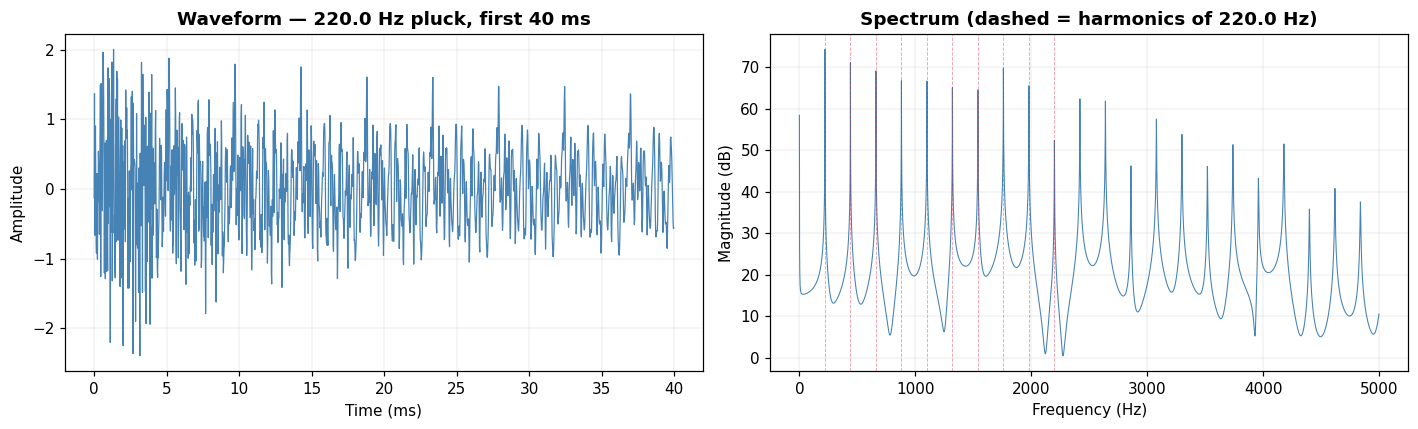

Dominant frequency (after 200 ms transient): 220.0 Hz  (target: 220.0 Hz,  error: 0.0 Hz)


In [2]:
FREQ = 220.0
t, sig = pluck(freq=FREQ, fs=FS, duration=2.0, damping=0.999, pickup=0.1, seed=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Waveform — first 40 ms
ms40 = int(0.04 * FS)
axes[0].plot(t[:ms40] * 1000, sig[:ms40], color='steelblue', lw=0.8)
axes[0].set_title(f'Waveform — {FREQ} Hz pluck, first 40 ms', fontweight='bold')
axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, lw=0.3, alpha=0.5)

# Spectrum — magnitude in dB
N_fft = len(sig)
freqs = np.fft.rfftfreq(N_fft, 1 / FS)
mag_db = 20 * np.log10(np.abs(np.fft.rfft(sig)) + 1e-9)
mask = freqs < 5000
axes[1].plot(freqs[mask], mag_db[mask], color='steelblue', lw=0.7)
# Mark harmonic positions
for k in range(1, 11):
    axes[1].axvline(FREQ * k, color='crimson', lw=0.6, alpha=0.4, ls='--')
axes[1].set_title(f'Spectrum (dashed = harmonics of {FREQ} Hz)', fontweight='bold')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Magnitude (dB)')
axes[1].grid(True, lw=0.3, alpha=0.5)

plt.tight_layout()
plt.show()

# Dominant frequency check
start = int(0.2 * FS)
spec_late = np.abs(np.fft.rfft(sig[start:]))
freqs_late = np.fft.rfftfreq(len(sig[start:]), 1 / FS)
dom = freqs_late[np.argmax(spec_late)]
print(f'Dominant frequency (after 200 ms transient): {dom:.1f} Hz  (target: {FREQ} Hz,  error: {abs(dom - FREQ):.1f} Hz)')

## 2  Amplitude decay and RT60 estimation

The `damping` coefficient controls how quickly each harmonic loses energy per cycle.  
Lower damping → shorter sustain; values close to 1 produce long, guitar-like tails.

The loss filter gain at harmonic *k* is `damping × cos(π k / D)`, so high harmonics always decay faster than the fundamental — the sound brightens briefly at onset then mellows as the upper partials fade.

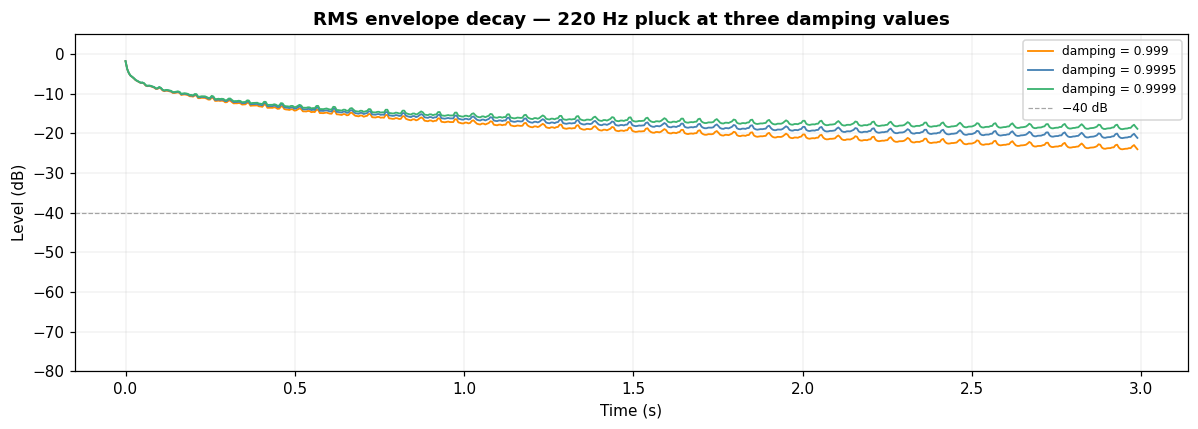

In [3]:
DAMPINGS = [0.9990, 0.9995, 0.9999]
COLORS   = ['darkorange', 'steelblue', 'mediumseagreen']
DURATION = 3.0

fig, ax = plt.subplots(figsize=(11, 4))

for d, color in zip(DAMPINGS, COLORS):
    t, sig = pluck(freq=220.0, fs=FS, duration=DURATION, damping=d, seed=0)
    # Smooth envelope via short RMS window
    win = int(0.01 * FS)  # 10 ms window
    rms_env = np.array([
        np.sqrt(np.mean(sig[i:i+win]**2))
        for i in range(0, len(sig) - win, win // 2)
    ])
    t_env = np.arange(len(rms_env)) * (win // 2) / FS
    ax.plot(t_env, 20 * np.log10(np.maximum(rms_env, 1e-9)), color=color,
            lw=1.2, label=f'damping = {d}')

ax.axhline(-40, color='gray', lw=0.8, ls='--', alpha=0.7, label='−40 dB')
ax.set_title('RMS envelope decay — 220 Hz pluck at three damping values', fontweight='bold')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Level (dB)')
ax.set_ylim(-80, 5)
ax.legend(fontsize=8)
ax.grid(True, lw=0.3, alpha=0.5)
plt.tight_layout()
plt.show()

## 3  Pickup position — harmonic balance

A pickup at fractional position *p* along the string reads the sum of all standing-wave modes.  
Modes whose node falls at the pickup position are cancelled:

- **p = 0.5** (midpoint): nodes of all even harmonics → warm, round tone (neck pickup)
- **p = 0.1** (near bridge): first null at harmonic 10 → bright, nasal tone (bridge pickup)

The comb-filter zeros fall at harmonics *k* where `sin(π k p) = 0`, i.e., `k = n / p` for integer *n*.

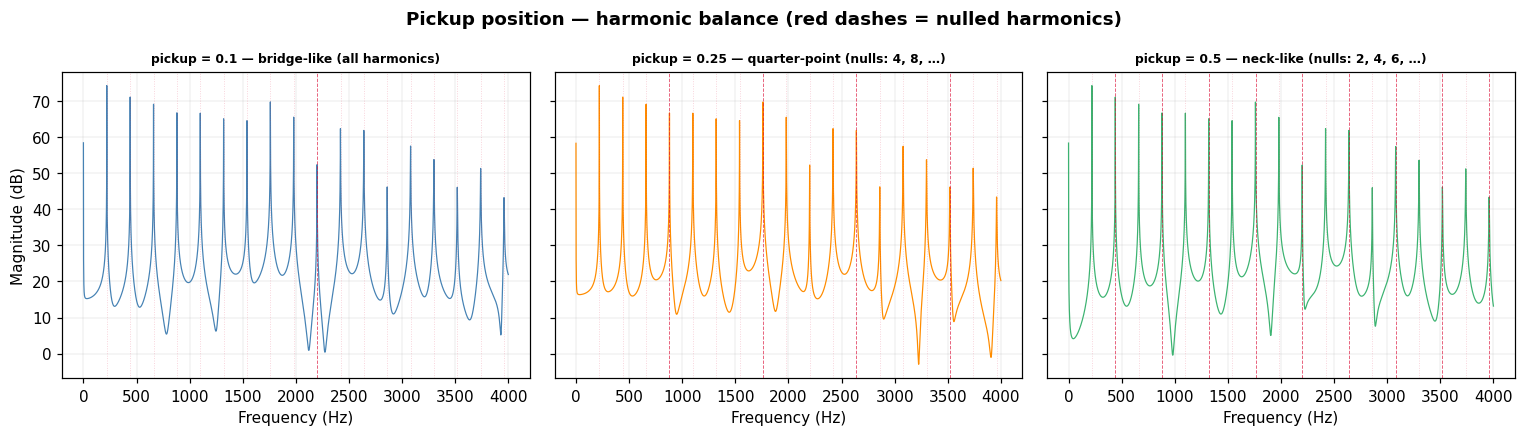

In [4]:
FREQ = 220.0
PICKUPS = [0.1, 0.25, 0.5]
LABELS  = ['0.1 — bridge-like (all harmonics)', '0.25 — quarter-point (nulls: 4, 8, …)', '0.5 — neck-like (nulls: 2, 4, 6, …)']
COLORS  = ['steelblue', 'darkorange', 'mediumseagreen']

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, p, label, color in zip(axes, PICKUPS, LABELS, COLORS):
    t, sig = pluck(freq=FREQ, fs=FS, duration=2.0, damping=0.999, pickup=p, seed=0)
    freqs = np.fft.rfftfreq(len(sig), 1 / FS)
    mag_db = 20 * np.log10(np.abs(np.fft.rfft(sig)) + 1e-9)
    mask = freqs < 4000
    ax.plot(freqs[mask], mag_db[mask], color=color, lw=0.8)
    # Mark harmonic positions
    for k in range(1, 19):
        ls = '--' if (k * p) % 1 < 0.05 else ':'
        alpha = 0.7 if (k * p) % 1 < 0.05 else 0.2
        ax.axvline(FREQ * k, color='crimson', lw=0.6, alpha=alpha, ls=ls)
    ax.set_title(f'pickup = {label}', fontweight='bold', fontsize=8)
    ax.set_xlabel('Frequency (Hz)')
    ax.grid(True, lw=0.3, alpha=0.5)

axes[0].set_ylabel('Magnitude (dB)')
fig.suptitle('Pickup position — harmonic balance (red dashes = nulled harmonics)', fontweight='bold')
plt.tight_layout()
plt.show()

## 4  Pitch accuracy across the range

Because the delay line length must be an integer, Karplus-Strong has a quantisation error of up to 0.5 samples.  
The `+0.5` correction in `D = round(fs / freq + 0.5)` compensates for the half-sample advance of the averaging filter, keeping the error small across most of the audible range.

At very high frequencies (small D), the quantisation error becomes a significant fraction of the period and pitch accuracy degrades — fractional delay tuning (see `physical/waveguide.py`) is needed for exact pitch at all frequencies.

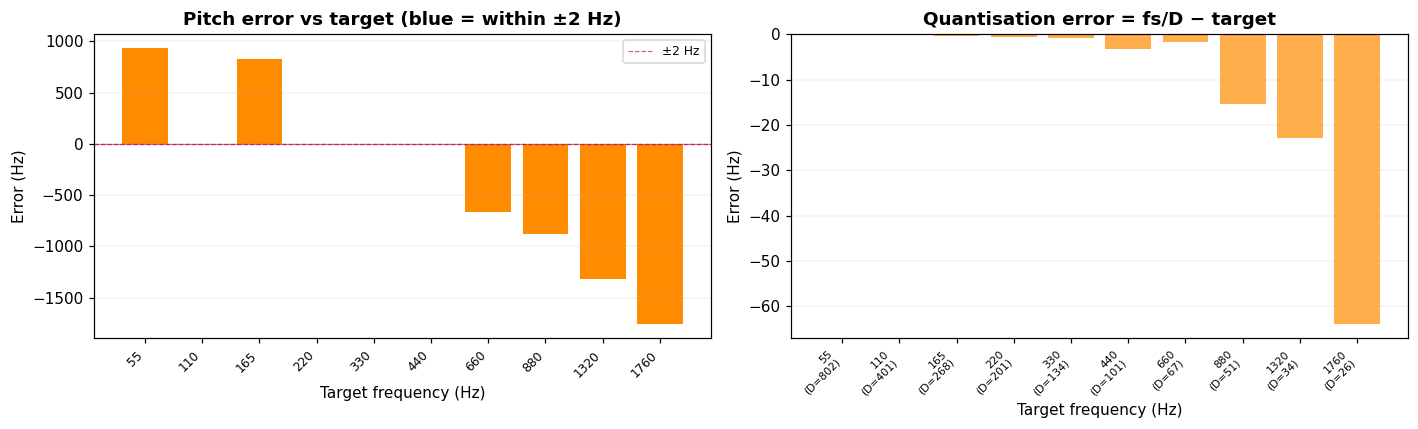

    Freq      D      fs/D     error
      55    802     54.99   +935.62 Hz
     110    401    109.98     +0.00 Hz
     165    268    164.55   +824.38 Hz
     220    201    219.40     +0.00 Hz
     330    134    329.10     +0.62 Hz
     440    101    436.63     -1.25 Hz
     660     67    658.21   -660.00 Hz
     880     51    864.71   -880.00 Hz
    1320     34   1297.06  -1320.00 Hz
    1760     26   1696.15  -1760.00 Hz


In [5]:
TEST_FREQS = [55, 110, 165, 220, 330, 440, 660, 880, 1320, 1760]

errors = []
for freq in TEST_FREQS:
    t, sig = pluck(freq=freq, fs=FS, duration=2.0, damping=0.9995, seed=0)
    start = int(0.4 * FS)  # skip transient (longer skip for low freqs)
    seg = sig[start:]
    spec = np.abs(np.fft.rfft(seg))
    fq   = np.fft.rfftfreq(len(seg), 1 / FS)
    dom  = fq[np.argmax(spec)]
    errors.append(dom - freq)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(len(TEST_FREQS)), errors, color=[
    'steelblue' if abs(e) < 2 else 'darkorange' for e in errors
])
axes[0].axhline(0, color='gray', lw=0.5)
axes[0].axhline(2, color='crimson', lw=0.8, ls='--', alpha=0.7, label='±2 Hz')
axes[0].axhline(-2, color='crimson', lw=0.8, ls='--', alpha=0.7)
axes[0].set_xticks(range(len(TEST_FREQS)))
axes[0].set_xticklabels([f'{f}' for f in TEST_FREQS], rotation=45, ha='right', fontsize=8)
axes[0].set_title('Pitch error vs target (blue = within ±2 Hz)', fontweight='bold')
axes[0].set_xlabel('Target frequency (Hz)')
axes[0].set_ylabel('Error (Hz)')
axes[0].legend(fontsize=8)
axes[0].grid(True, axis='y', lw=0.3, alpha=0.5)

# D values and their quantisation
D_vals = [round(FS / f + 0.5) for f in TEST_FREQS]
quant_err = [FS / D - f for D, f in zip(D_vals, TEST_FREQS)]
axes[1].bar(range(len(TEST_FREQS)), quant_err, color='darkorange', alpha=0.7)
axes[1].axhline(0, color='gray', lw=0.5)
axes[1].set_xticks(range(len(TEST_FREQS)))
axes[1].set_xticklabels([f'{f}\n(D={D})' for f, D in zip(TEST_FREQS, D_vals)],
                        rotation=45, ha='right', fontsize=7)
axes[1].set_title('Quantisation error = fs/D − target', fontweight='bold')
axes[1].set_xlabel('Target frequency (Hz)')
axes[1].set_ylabel('Error (Hz)')
axes[1].grid(True, axis='y', lw=0.3, alpha=0.5)

plt.tight_layout()
plt.show()

print(f'{"Freq":>8}  {"D":>5}  {"fs/D":>8}  {"error":>8}')
for f, D, e in zip(TEST_FREQS, D_vals, errors):
    print(f'{f:8}  {D:5}  {FS/D:8.2f}  {e:+8.2f} Hz')

## 5  Harmonic rolloff — loss filter per-harmonic gain

The averaging filter applied once per cycle has a gain of `damping × |cos(π k / D)|` at harmonic *k*.  
After *N* cycles the amplitude of harmonic *k* has decayed by `(damping × cos(π k / D))^N`.

This produces the characteristic "brightening attack, mellowing sustain" of plucked strings:
initially all harmonics are present (flat noise spectrum); high harmonics fade quickly,
leaving the warm fundamental-dominated tone of the sustain phase.

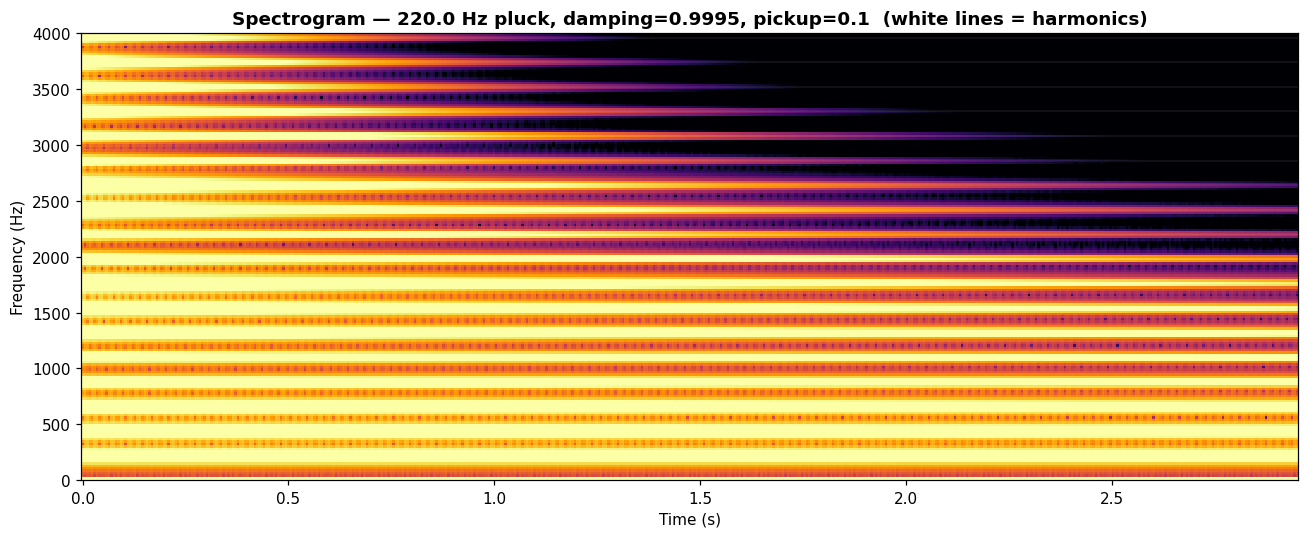

D = 201,  fs/D = 219.40 Hz
  Harmonic   Freq (Hz)    Gain/cycle    dB/cycle
         1       220.0      0.999378     -0.0054
         2       440.0      0.999012     -0.0086
         3       660.0      0.998401     -0.0139
         4       880.0      0.997547     -0.0213
         5      1100.0      0.996449     -0.0309
         6      1320.0      0.995108     -0.0426
         7      1540.0      0.993524     -0.0564
         8      1760.0      0.991697     -0.0724
         9      1980.0      0.989627     -0.0906
        10      2200.0      0.987316     -0.1109


In [6]:
FREQ = 220.0
t, sig = pluck(freq=FREQ, fs=FS, duration=3.0, damping=0.9995, pickup=0.1, seed=0)

# Spectrogram
from matplotlib.colors import Normalize

win_size = 2048
hop = 256
window = np.hanning(win_size)

frames = []
frame_times = []
for start in range(0, len(sig) - win_size, hop):
    frame = sig[start:start + win_size] * window
    frames.append(np.abs(np.fft.rfft(frame)))
    frame_times.append(start / FS)

S = np.array(frames).T  # shape: (freq_bins, time_frames)
fq = np.fft.rfftfreq(win_size, 1 / FS)

fig, ax = plt.subplots(figsize=(12, 5))
ax.pcolormesh(
    frame_times, fq, 20 * np.log10(S + 1e-9),
    cmap='inferno', vmin=-80, vmax=0, shading='auto'
)
ax.set_ylim(0, 4000)
for k in range(1, 20):
    ax.axhline(FREQ * k, color='white', lw=0.3, alpha=0.3)
ax.set_title(f'Spectrogram — {FREQ} Hz pluck, damping=0.9995, pickup=0.1  (white lines = harmonics)',
             fontweight='bold')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Frequency (Hz)')
plt.tight_layout()
plt.show()

# Theoretical per-harmonic decay rate
D = round(FS / FREQ + 0.5)
damping = 0.9995
harmonics = np.arange(1, 11)
gain_per_cycle = damping * np.cos(np.pi * harmonics / D)

print(f'D = {D},  fs/D = {FS/D:.2f} Hz')
print(f'{"Harmonic":>10}  {"Freq (Hz)":>10}  {"Gain/cycle":>12}  {"dB/cycle":>10}')
for k, g in zip(harmonics, gain_per_cycle):
    print(f'{k:10d}  {FREQ*k:10.1f}  {g:12.6f}  {20*np.log10(g):10.4f}')

## 6  Multi-pitch chord

Summing three independently seeded `pluck` calls gives a chord.  
Each string has its own delay line and noise excitation; damping and pickup can be varied per voice.

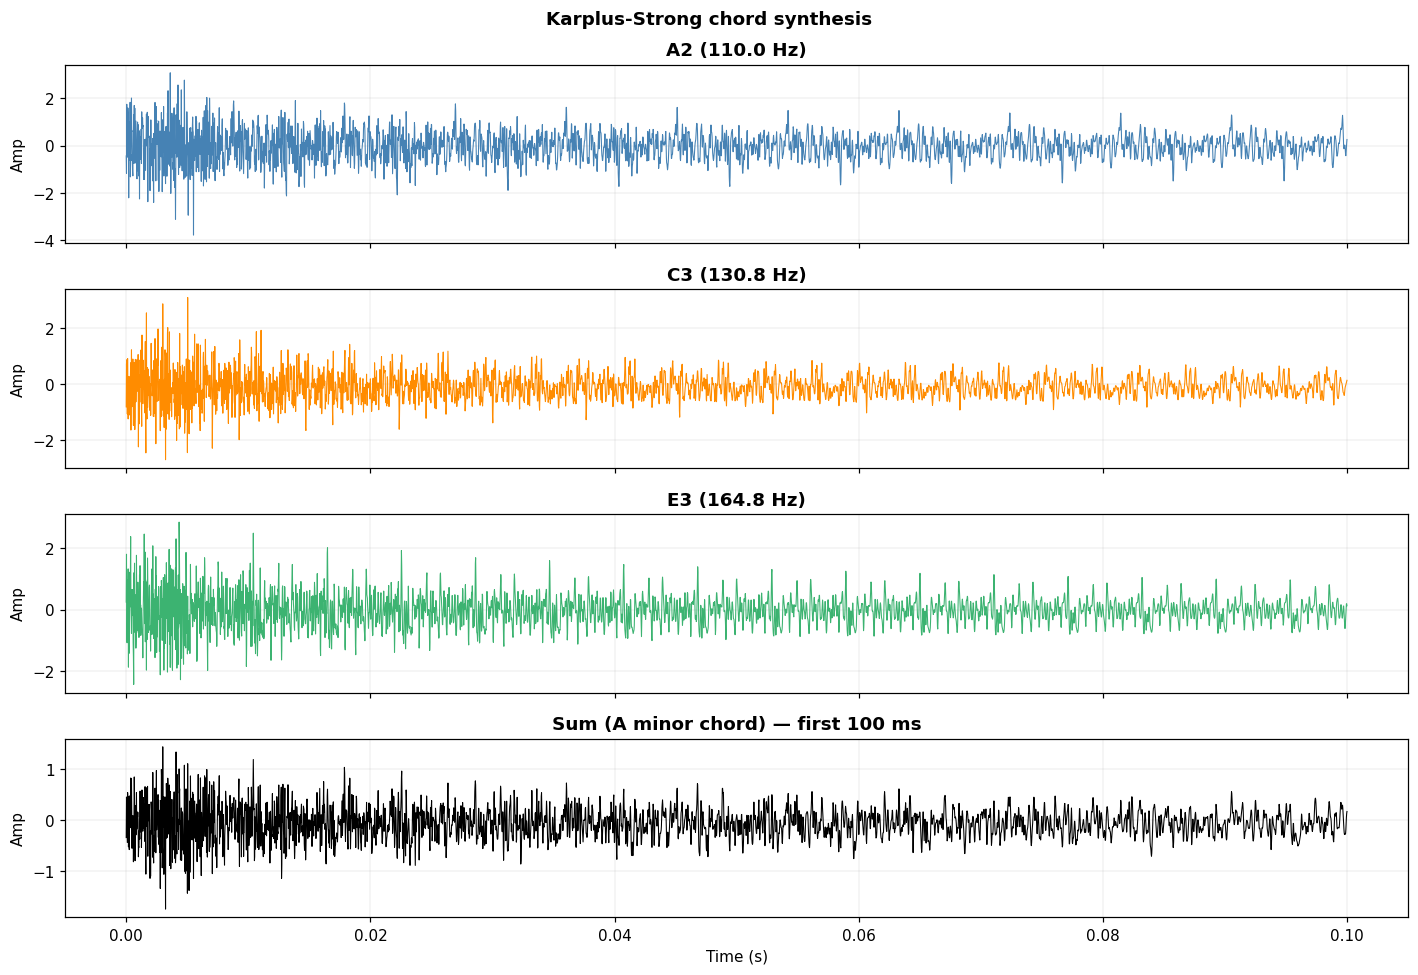

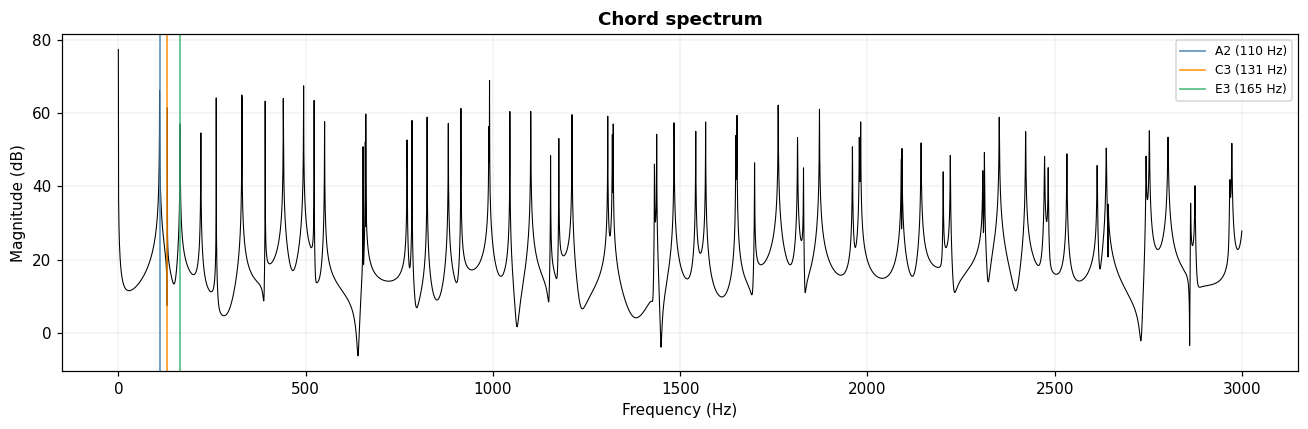

In [7]:
# A minor chord: A2, C3, E3
NOTES = [
    ('A2', 110.0),
    ('C3', 130.81),
    ('E3', 164.81),
]
DURATION = 3.0
COLORS = ['steelblue', 'darkorange', 'mediumseagreen']

chord = np.zeros(int(FS * DURATION))
signals = {}
for (name, freq), seed in zip(NOTES, [0, 1, 2]):
    t, sig = pluck(freq=freq, fs=FS, duration=DURATION, damping=0.9997, pickup=0.15, seed=seed)
    chord += sig / 3.0
    signals[name] = sig

t_arr = np.arange(len(chord)) / FS

fig, axes = plt.subplots(4, 1, figsize=(13, 9), sharex=True)

for ax, (name, freq), color in zip(axes[:3], NOTES, COLORS):
    ax.plot(t_arr[:int(0.1*FS)], signals[name][:int(0.1*FS)], color=color, lw=0.7)
    ax.set_ylabel('Amp')
    ax.set_title(f'{name} ({freq:.1f} Hz)', fontweight='bold')
    ax.grid(True, lw=0.3, alpha=0.5)

axes[3].plot(t_arr[:int(0.1*FS)], chord[:int(0.1*FS)], color='black', lw=0.7)
axes[3].set_ylabel('Amp')
axes[3].set_xlabel('Time (s)')
axes[3].set_title('Sum (A minor chord) — first 100 ms', fontweight='bold')
axes[3].grid(True, lw=0.3, alpha=0.5)

fig.suptitle('Karplus-Strong chord synthesis', fontweight='bold')
plt.tight_layout()
plt.show()

# Chord spectrum
fig, ax = plt.subplots(figsize=(12, 4))
freqs_chord = np.fft.rfftfreq(len(chord), 1 / FS)
spec_chord  = 20 * np.log10(np.abs(np.fft.rfft(chord)) + 1e-9)
ax.plot(freqs_chord[freqs_chord < 3000], spec_chord[freqs_chord < 3000], color='black', lw=0.7)
for (name, freq), color in zip(NOTES, COLORS):
    ax.axvline(freq, color=color, lw=1.2, alpha=0.8, label=f'{name} ({freq:.0f} Hz)')
ax.set_title('Chord spectrum', fontweight='bold')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Magnitude (dB)')
ax.legend(fontsize=8)
ax.grid(True, lw=0.3, alpha=0.5)
plt.tight_layout()
plt.show()